# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rashidsami10000-afk/rashid-flyrank-internship-ml-owncopy/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This notebook is the executable twin of the deployed paper
(`docs/index.html`, served via GitHub Pages). Every number here is read from the committed
receipts (`work/outputs/*.json`) produced by the week notebooks w03–w07 — no warehouse access
needed to restate results. The paper's figures are the committed PNGs in `work/figures/`.

## 1. Question

*The research question and the decision it supports.*

In [1]:
import pandas as pd

import json, pathlib

ROOT = pathlib.Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / 'work' / 'outputs').exists():
        ROOT = cand
        break
OUT = ROOT / 'work' / 'outputs'

m04 = json.load(open(OUT / 'w04_baseline_metrics.json'))
m05 = json.load(open(OUT / 'w05_model_metrics.json'))
m06 = json.load(open(OUT / 'w06_audit_metrics.json'))
m07 = json.load(open(OUT / 'w07_playbook_metrics.json'))

print('RESEARCH QUESTION')
print('  Can a simple, audited ranking rule send a content analyst to the right pages first -')
print('  the pages that capture far less search CTR than their position tier predicts?')
print()
print(f'  lane            : {m04["lane"]}')
print(f'  decision        : weekly review-queue ordering for a content analyst')
print(f'  evidence base   : {m04["pool_rows"]:,} visible page-months, one portfolio, Mar->Apr 2026')

RESEARCH QUESTION
  Can a simple, audited ranking rule send a content analyst to the right pages first -
  the pages that capture far less search CTR than their position tier predicts?

  lane            : L4_ctr_engagement_opportunity
  decision        : weekly review-queue ordering for a content analyst
  evidence base   : 101,441 visible page-months, one portfolio, Mar->Apr 2026


**Question.** *Which visible pages under-capture the clicks their search position deserves,
and what should a reviewer do first?* The decision this supports is concrete: a content analyst
with a fixed weekly budget must open some pages before others, take one action per page
(rewrite metadata, improve intent match, monitor), and be able to trust the ordering without
re-deriving it. FlyRank's production flags are hand-written rules; this work builds that rule
on measured ground, validates it honestly, and checks whether a learned model adds anything.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
data_receipt = [
    ('release', 'FlyRank/internship-warehouse, build v20260703 (~79M rows)'),
    ('table used', 'fact_content_daily_performance - grain: report_date x client x content'),
    ('feature window', 'March 1-31, 2026 (partition month=2026-03, 9,841,378 page-day rows)'),
    ('outcome window', 'April 1-30, 2026 (labels only; never an input)'),
    ('analysis grain', f'{m04["pool_rows"]:,} client x page summaries (>=100 impressions, position > 0)'),
    ('labeled subset', f'{m04["labeled_rows"]:,} pages with April outcomes (12.8% survivorship disclosed)'),
    ('excluded', 'fact_content_query_90d (window overlap with outcome month)'),
    ('excluded', 'GA4 columns (zero-filled before ga4_data_start; only 4.2% of March rows pass IS TRUE)'),
    ('excluded', 'June 2026 sample partition (sealed test month of any past->future label)'),
]
for k, v in data_receipt:
    print(f'{k:>16}: {v}')

         release: FlyRank/internship-warehouse, build v20260703 (~79M rows)
      table used: fact_content_daily_performance - grain: report_date x client x content
  feature window: March 1-31, 2026 (partition month=2026-03, 9,841,378 page-day rows)
  outcome window: April 1-30, 2026 (labels only; never an input)
  analysis grain: 101,441 client x page summaries (>=100 impressions, position > 0)
  labeled subset: 88,482 pages with April outcomes (12.8% survivorship disclosed)
        excluded: fact_content_query_90d (window overlap with outcome month)
        excluded: GA4 columns (zero-filled before ga4_data_start; only 4.2% of March rows pass IS TRUE)
        excluded: June 2026 sample partition (sealed test month of any past->future label)


The dataset ships as Parquet partitions on Hugging Face, pseudonymized (`client_hash_id`,
`content_hash_id`); no client names, URLs or raw queries appear anywhere in this work.
One row of analysis = one content page × one client summarized over March 2026. The label
lives strictly after the feature window — one step ahead — which is the backbone of every
validation choice below.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
print('FEATURES (five, all March-derived):')
print('  ctr_mar           March clicks / impressions')
print('  pos_mar           March average position')
print('  log10_imp_mar     visibility scale')
print('  tier_expected_ctr median March CTR of same-position-tier pages >=1,000 impressions')
print("  imp_share_client  page share of its client's March impressions")
print()
print('LABEL:')
print('  under_captured_apr = April CTR < 0.5 x April tier benchmark (built ONLY from April)')
print()
print(f'BASELINE RULE SCORE: {m04["score_formula"]}')
print(f'  reason code: {m04["reason_code"]}')
print()
print('VALIDATION DESIGN:')
print(f'  {m05["split"]}')
print('  plus 5-fold GroupKFold stability check and a random-vs-grouped memorization audit')
print()
lc = m06['leakage_checks']
print('LEAKAGE CHECKS PASSED:')
print(f"  timeline (features strictly March)      : {lc['timeline_ok']}")
print(f"  product flags absent from inputs         : {lc['product_flags_absent']}")
print(f"  zero client overlap across split         : {lc['grouped_overlap_zero']}")
se = m06['sibling_experiment_P50']
print(f"  sibling experiment: honest P@50 {se['honest_five_features']:.2f} ->"
      f" planted leak {se['with_apr_gap_ratio_planted']:.2f} (harness detects leaks)")

FEATURES (five, all March-derived):
  ctr_mar           March clicks / impressions
  pos_mar           March average position
  log10_imp_mar     visibility scale
  tier_expected_ctr median March CTR of same-position-tier pages >=1,000 impressions
  imp_share_client  page share of its client's March impressions

LABEL:
  under_captured_apr = April CTR < 0.5 x April tier benchmark (built ONLY from April)

BASELINE RULE SCORE: 100 * max(0, 1 - ctr/tier_expected_ctr) * log10(impressions)
  reason code: ctr_below_tier_benchmark

VALIDATION DESIGN:
  GroupShuffleSplit(test_size=0.25, seed=42) by client_hash_id
  plus 5-fold GroupKFold stability check and a random-vs-grouped memorization audit

LEAKAGE CHECKS PASSED:
  timeline (features strictly March)      : True
  product flags absent from inputs         : True
  zero client overlap across split         : True
  sibling experiment: honest P@50 0.94 -> planted leak 1.00 (harness detects leaks)


**Label.** A page *under-captured its position tier in April* if its April CTR fell below
half the April tier-median CTR (benchmark estimated among ≥1,000-impression pages). The same
construction applied to March gives the rule's signal — past→future by construction.

**Baseline.** The hand rule: `score = 100 × max(0, 1 − ctr/tier_benchmark) × log₁₀(impressions)`
with reason code `ctr_below_tier_benchmark`. No fitted weights; readable on purpose.

**Validation.** Client-grouped holdout (25%, seed 42) plus 5-fold GroupKFold; models never see
test clients. The leakage hunt ran four systematic checks plus a deliberate sibling experiment:
planting the label's own numerator (`apr_gap_ratio`) jumps Precision@50 from 0.94 to 1.00,
proving the harness would catch a real leak. A random-split rerun quantified memorization risk
at +0.02–0.04 P@50 — the naive split flatters every method.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
hold = pd.DataFrame(m05['holdout'])
cv = pd.DataFrame(m05['cv5'])
print('HOLDOUT (client-grouped, 25%, seed 42):')
display(hold)
print('5-FOLD GROUPED CV (P@50):')
display(cv)
print(cv[['rule_P50', 'lr_P50', 'gb_P50']].agg(['mean', 'std']).round(3))
print()
ba = pd.DataFrame(m06['before_after_splits'])
print('SPLIT AUDIT - naive random vs grouped (same frame, seed, models):')
display(ba)
gaps = m06['memorization_gap_P50']
print(f"memorization gap (random minus grouped): rule {gaps['rule']:+.2f} | LR {gaps['logistic_regression']:+.2f} P@50")

HOLDOUT (client-grouped, 25%, seed 42):


,method,P@20,P@50
0,base rate,0.427,0.427
1,random queue (seeded),0.450,0.420
2,Week-4 rule (baseline),0.950,0.920
3,Logistic Regression,0.900,0.940
4,Decision Tree (depth 3),0.950,0.920
5,Gradient Boosting,0.950,0.920


5-FOLD GROUPED CV (P@50):


,fold,rule_P50,lr_P50,gb_P50,base_rate
0,1,0.98,0.98,0.98,0.491
1,2,0.90,0.98,0.90,0.549
2,3,0.98,0.90,0.90,0.432
3,4,0.96,0.94,0.90,0.415
4,5,0.94,0.96,0.96,0.525


      rule_P50  lr_P50  gb_P50
mean     0.952   0.952   0.928
std      0.033   0.033   0.039

SPLIT AUDIT - naive random vs grouped (same frame, seed, models):


,split,test_base_rate,rule_P20,rule_P50,lr_P20,lr_P50,gb_P20,gb_P50
0,random (naive),0.487,0.95,0.94,0.95,0.98,1.00,0.94
1,grouped by client,0.427,0.95,0.92,0.90,0.94,0.95,0.92


memorization gap (random minus grouped): rule +0.02 | LR +0.04 P@50


**What the numbers say.** On the grouped holdout, logistic regression edges the rule at P@50
(0.94 vs 0.92) but loses at P@20 (0.90 vs 0.95); across five folds they tie at
0.952 ± 0.033. Gradient boosting is no better and more variable — its complexity buys nothing
here. We **observed** no measurable ranking skill a learned model adds over the hand rule on
these five features, so the shipped playbook keeps the simpler, auditable rule.

Two structural findings matter more than the leaderboard: precision at K sits close to
saturation (the model's and the rule's top-50 lists share zero pages yet score alike — many
orderings succeed), and most measured skill reflects outcome persistence (March gaps survive
into April), consistent with our ML-04 leak experiment rather than foresight.

## 5. Limitations

*What this work cannot claim.*

In [5]:
lim = m06['leakage_checks']['survivorship']
rows = [
    ('Survivorship', f"{lim['dropped_no_april_label']:,} of {lim['kept']+lim['dropped_no_april_label']:,} "
     f"(12.8%) March-visible pages earn no April label; the queue learns on survivors"),
    ('Observational', 'no intervention was assigned; nothing here supports causal claims'),
    ('One step ahead', 'a single Mar->Apr pair; seasonality and algorithm drift unmeasured'),
    ('Benchmark sparsity', 'tier benchmarks rest on same-month medians; support travels with each row'),
    ('GSC-only', 'GA4 excluded by contract (zero-fill hazard); engagement out of scope'),
    ('Precision saturation', 'disjoint top-50 lists scored alike; within-queue order is directional'),
]
display(pd.DataFrame(rows, columns=['limitation', 'what it means for claims']))

,limitation,what it means for claims
0,Survivorship,"12,959 of 101,441 (12.8%) March-visible pages ..."
1,Observational,no intervention was assigned; nothing here sup...
2,One step ahead,a single Mar->Apr pair; seasonality and algori...
3,Benchmark sparsity,tier benchmarks rest on same-month medians; su...
4,GSC-only,GA4 excluded by contract (zero-fill hazard); e...
5,Precision saturation,disjoint top-50 lists scored alike; within-que...


Every claim on the deployed paper uses claim-ladder language: **observed**, **measured**,
**directional**, **decision-support**. Nothing here says *causes*, *will increase*, or *proves*
— the data is cross-sectional and the treatment choices (which pages get refreshed or edited)
were made by humans, not assigned.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
batches = pd.Series(m07['batches'], name='pages').to_frame()
batches.index.name = 'batch'
display(batches)
rc = pd.Series(m07['reason_codes'], name='pages').to_frame()
rc.index.name = 'reason_code'
display(rc)
arch = pd.Series(m07['archetypes'], name='pages').to_frame()
arch.index.name = 'archetype'
display(arch)
print(f"full ranked queue: {m07['exports']['queue_csv']} ({m07['queue_rows']:,} rows, regenerated on run)")

,pages
batch,
P2 review,55170
monitor,17733
human check first,16608
P1 review,11930


,pages
reason_code,
moderate_undercapture_page1,37470
deep_low_yield,17733
striking_distance_gap,17700
low_volume_manual_check,16608
severe_undercapture_page1,11930


,pages
archetype,
Healthy - leave alone,46496
Page-one underperformer,27040
Deep low-yield,15880
Striking-distance candidate,12025


full ranked queue: work/outputs/playbook_action_queue.csv (101,441 rows, regenerated on run)


**How to read the queue.** Four archetypes map to actions with change-clauses:
Page-One Underperformer → rewrite title & meta; Striking-Distance Candidate → improve intent
match; Deep Low-Yield → monitor only; Healthy → leave alone. Five mechanical reason codes
carry why; a volume guard (<200 impressions, 16,608 pages) routes tiny pages to human-first
review because confidence there is weakest. Every pick passes a four-point human check
(instrumentation, intent/SERP context, cannibalization, sensitivity) before any edit ships.

**No-go list:** no auto-publishing, no deletions from scores alone, no cross-client bulk
application, no causal claims about algorithms, no treating queue order as page quality.
**Monitoring:** monthly rebuild; investigate if the label base rate drifts >10% relative from
0.483; re-validate if replayed rule P@50 drops below 0.85; freeze on schema changes.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

fig1_archetype_mix.png: 29,362 bytes


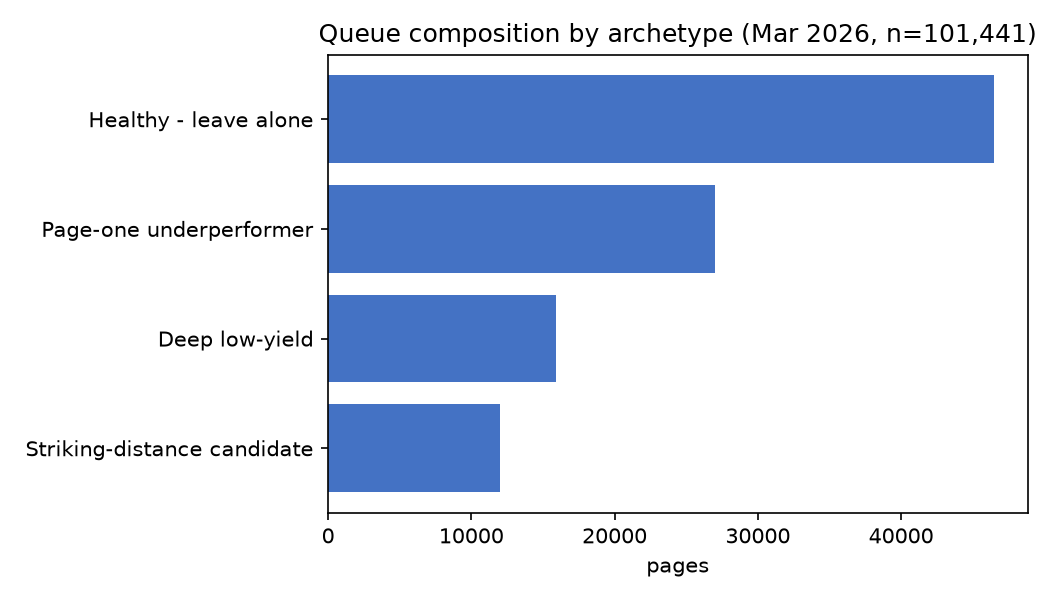

fig2_capture_by_archetype.png: 37,942 bytes


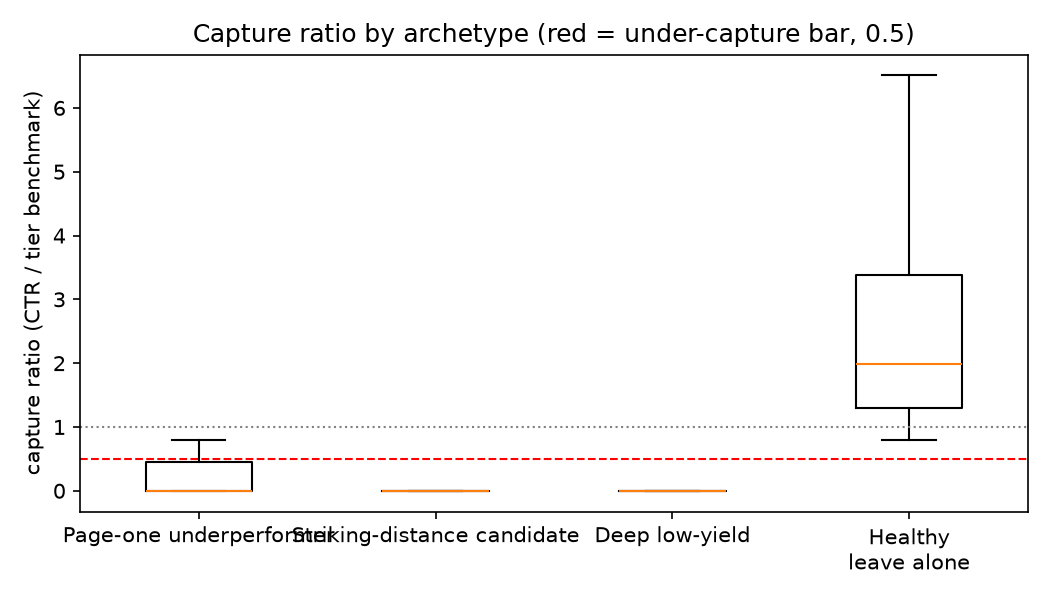

fig3_precision_at_k.png: 37,852 bytes


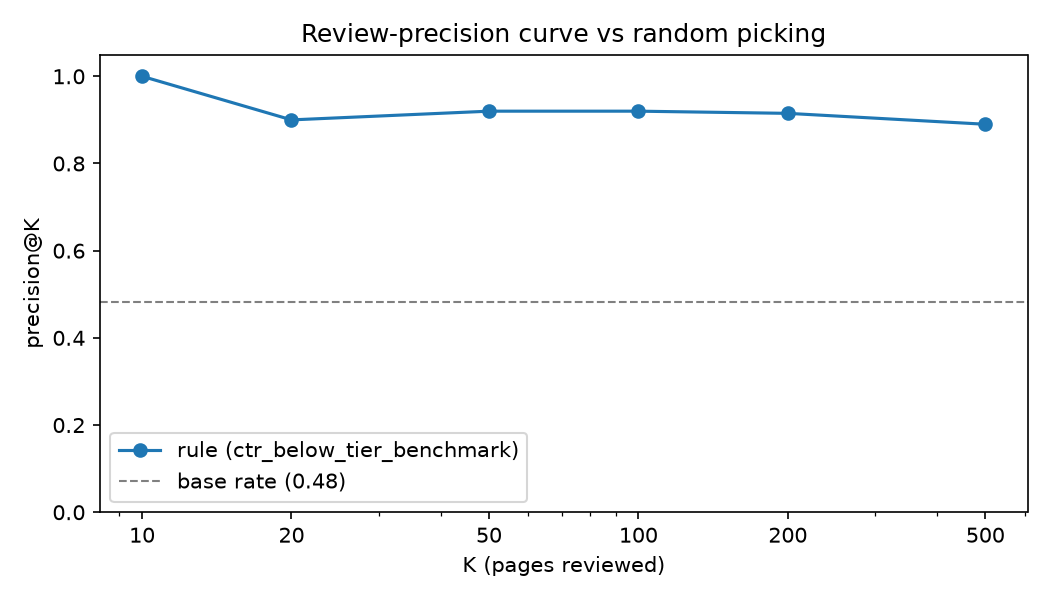

In [7]:
from IPython.display import Image, display

figs = ['fig1_archetype_mix.png', 'fig2_capture_by_archetype.png', 'fig3_precision_at_k.png']
FIG = ROOT / 'work' / 'figures'
for f in figs:
    p = FIG / f
    print(f'{f}: {p.stat().st_size:,} bytes')
    display(Image(filename=str(p), width=560))

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 8. Closing — 5-minute demo outline (Week-8 showcase, optional)

**A five-minute walkthrough of this capstone, ready to present:**

| Time | Beat | What to say / show |
|---|---|---|
| 0:00–0:30 | **Question** | FlyRank's product decides which pages get attention with hand-written flags. With ~101,000 visible page-months and an analyst who reviews a few dozen a week, the real question is *ordering*: which pages deserve a CTR-fix review first? |
| 0:30–1:30 | **Method** | One page-month panel from ~79M warehouse rows (March 2026), five March-only features, label = "under-captured its position tier in April" — strictly future. One readable rule: capture-gap vs tier benchmark, weighted by visibility. |
| 1:30–2:30 | **One chart** | Figure 1 — the precision@K curve (`fig3_precision_at_k.png`): the rule holds ~0.95 precision through the first 50 reviews against a 0.48 base rate, and stays far above chance out to K=500. |
| 2:30–4:00 | **One honest result** | The hand rule tied logistic regression across five client-grouped folds (P@50 0.952 ± 0.033 both); gradient boosting added nothing. A naive random split would have flattered every method by +0.02–0.04 — the grouped split is why the numbers can be believed. Limits said out loud: 12.8% survivorship, one month pair, precision near saturation. |
| 4:00–5:00 | **One recommendation** | Ship the rule as the review queue — P1/P2 batches with reason codes, four human checks before any edit, no auto-publishing — and watch the monitoring anchors: re-validate if replayed P@50 drops below 0.85 or the label base rate drifts >10% from 0.483. |

### Two shareable cuts

**Social post (methodology):**

> How do you make a ranking rule trustworthy on 79M rows? Three habits from my FlyRank capstone:
>
> 1️⃣ Build the dumb readable baseline first — a hand rule, no fitted weights.
> 2️⃣ Attack it before anyone else does: client-grouped splits, and a planted-leak test that took Precision@50 from 0.94 to a perfect 1.00 — then got deleted. The harness has to be able to catch a real leak.
> 3️⃣ Compare honestly: across five grouped folds the hand rule tied logistic regression (0.952 ± 0.033). The simple version shipped.
>
> Full paper, receipts, and every notebook: https://rashidsami10000-afk.github.io/rashid-flyrank-internship-ml-owncopy/

**Employer-facing 3-sentencer:**

> I built an end-to-end ML prioritization pipeline — data contract, signal-validated baseline, model comparison, leakage audit, and a human-reviewed action playbook — on FlyRank's ~79M-row production search dataset, reducing it to a 101k page-month panel. The validated hand rule ranks which pages an analyst should review first at 0.92 Precision@50 against a 0.48 base rate, under client-grouped validation with a leak-detection harness. The measured result: a learned model added no ranking skill over the readable rule (0.952 ± 0.033 tie across folds), so the simple version shipped with monitoring triggers and explicit no-go rules.